# 🧠 Brain Tumor Classifier — EfficientNet-B0 (PyTorch)
**Classes :** `glioma` | `meningioma` | `notumor` | `pituitary`

**Pipeline :**
1. Chargement & exploration du dataset
2. Data augmentation
3. Entraînement en 2 phases (Transfer Learning + Fine-tuning)
4. Évaluation : accuracy, F1, confusion matrix, ROC
5. Prédiction sur une image unique

---
**Structure du dataset attendue :**
```
dataset/
  Training/
    glioma/        meningioma/
    notumor/       pituitary/
  Testing/
    glioma/        meningioma/
    notumor/       pituitary/
```

## 0. Installation des dépendances

In [ ]:
# Exécuter si les packages ne sont pas installés
# !pip install torch torchvision scikit-learn seaborn matplotlib Pillow

## 1. Imports & Configuration

In [1]:
import os, time, copy, json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize

# ── Config ──────────────────────────────────────
DATA_DIR      = "./brain-tumor-mri-dataset"          # ← MODIFIE ICI
SAVE_DIR      = "./output"
CLASS_NAMES   = ["glioma", "meningioma", "notumor", "pituitary"]
NUM_CLASSES   = 4
IMG_SIZE      = 224
BATCH_SIZE    = 32
NUM_EPOCHS    = 30
PHASE1_EPOCHS = 10
LR_HEAD       = 1e-3
LR_FINETUNE   = 1e-4
DROPOUT       = 0.4
SEED          = 42
COLORS        = {"glioma": "#e74c3c", "meningioma": "#f39c12",
                 "notumor": "#27ae60", "pituitary": "#2980b9"}

torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
os.makedirs(SAVE_DIR, exist_ok=True)

print(f"✅ Dispositif : {device}")
print(f"📁 Dataset    : {DATA_DIR}")

✅ Dispositif : cpu
📁 Dataset    : ./brain-tumor-mri-dataset


## 2. Exploration du Dataset

In [2]:
# Compte les images par classe
for split in ["Training", "Testing"]:
    split_path = Path(DATA_DIR) / split
    if not split_path.exists():
        print(f"❌ {split_path} introuvable")
        continue
    print(f"\n📂 {split}")
    total = 0
    for cls_dir in sorted(split_path.iterdir()):
        if cls_dir.is_dir():
            n = len(list(cls_dir.glob("*")))
            bar = "█" * (n // 50)
            print(f"  {cls_dir.name:12s}: {n:4d} images  {bar}")
            total += n
    print(f"  {'TOTAL':12s}: {total:4d} images")


📂 Training
  glioma      : 1321 images  ██████████████████████████
  meningioma  : 1339 images  ██████████████████████████
  notumor     : 1595 images  ███████████████████████████████
  pituitary   : 1457 images  █████████████████████████████
  TOTAL       : 5712 images

📂 Testing
  glioma      :  300 images  ██████
  meningioma  :  306 images  ██████
  notumor     :  405 images  ████████
  pituitary   :  300 images  ██████
  TOTAL       : 1311 images


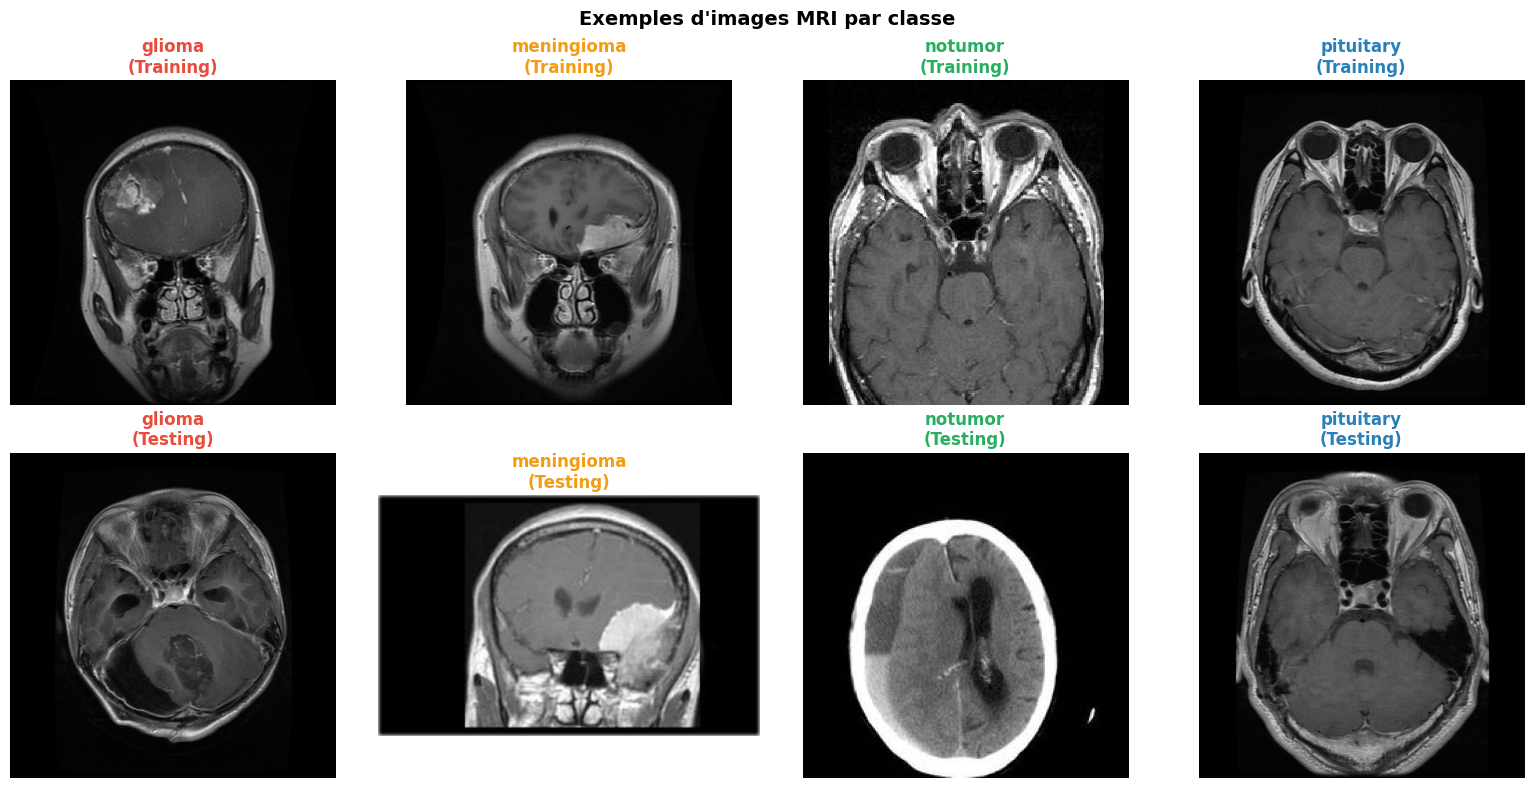

In [3]:
# Afficher des exemples d'images
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Exemples d'images MRI par classe", fontsize=14, fontweight="bold")

for row, split in enumerate(["Training", "Testing"]):
    for col, cls in enumerate(CLASS_NAMES):
        cls_dir = Path(DATA_DIR) / split / cls
        if cls_dir.exists():
            imgs = list(cls_dir.glob("*.jpg")) + list(cls_dir.glob("*.png"))
            if imgs:
                img = Image.open(imgs[0]).convert("RGB")
                axes[row, col].imshow(img, cmap="gray")
                axes[row, col].set_title(f"{cls}\n({split})",
                                          color=COLORS[cls], fontweight="bold")
        axes[row, col].axis("off")

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/sample_images.png", dpi=120, bbox_inches="tight")
plt.show()

## 3. Data Augmentation & DataLoaders

In [4]:
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE + 20, IMG_SIZE + 20)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

train_ds = datasets.ImageFolder(f"{DATA_DIR}/Training", transform=train_tf)
test_ds_full = datasets.ImageFolder(f"{DATA_DIR}/Testing", transform=val_tf)

val_size  = len(test_ds_full) // 2
test_size = len(test_ds_full) - val_size
val_ds, test_ds = torch.utils.data.random_split(
    test_ds_full, [val_size, test_size],
    generator=torch.Generator().manual_seed(SEED)
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train : {len(train_ds):4d} images | Val : {val_size:4d} | Test : {test_size:4d}")
print(f"Classes détectées : {train_ds.classes}")

Train : 5712 images | Val :  655 | Test :  656
Classes détectées : ['glioma', 'meningioma', 'notumor', 'pituitary']


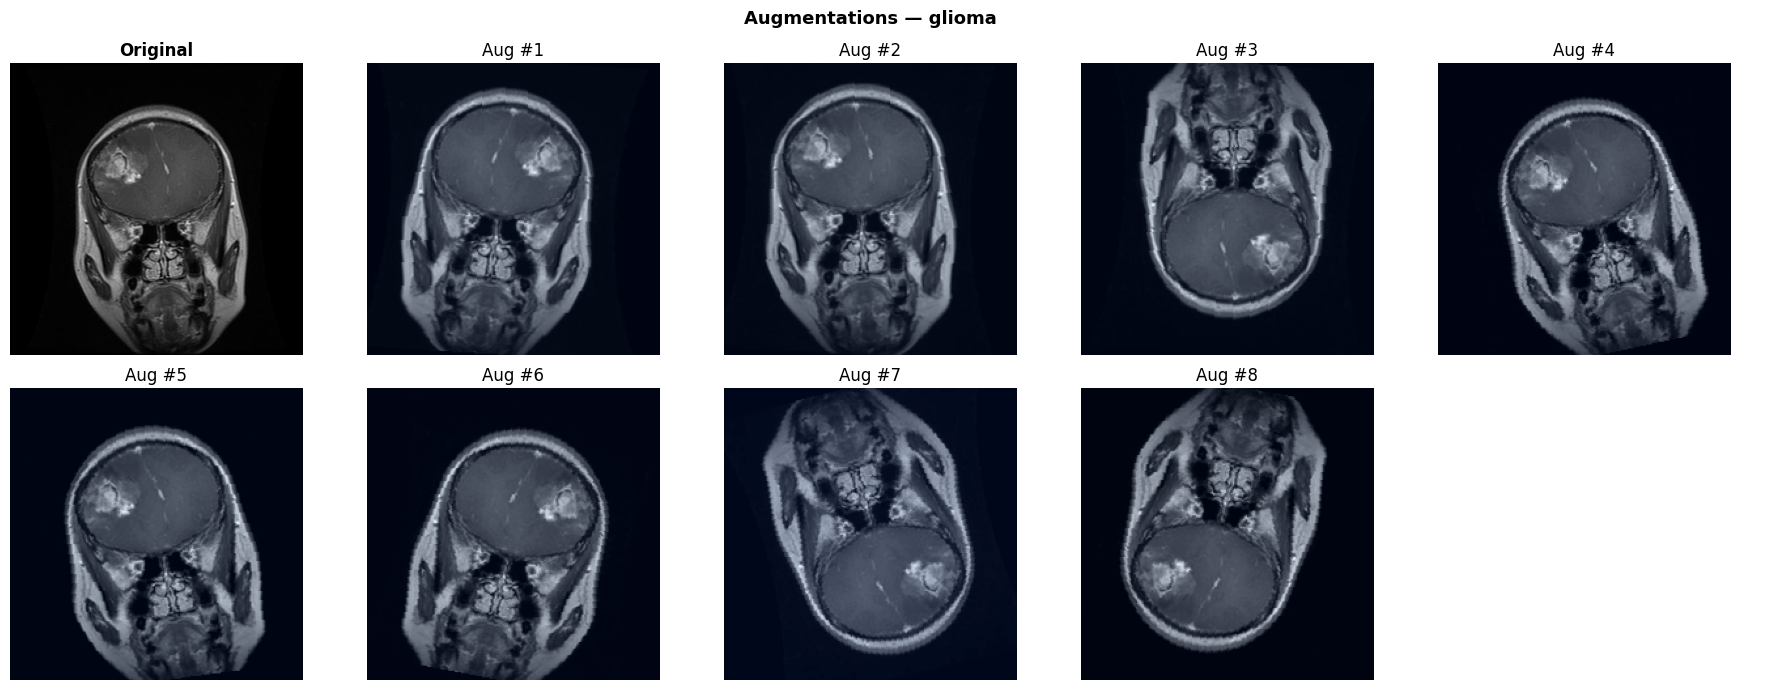

In [5]:
# Visualiser les augmentations
img_path = list((Path(DATA_DIR) / "Training" / CLASS_NAMES[0]).glob("*"))[0]
raw_img  = Image.open(img_path).convert("RGB")

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
fig.suptitle(f"Augmentations — {CLASS_NAMES[0]}", fontsize=13, fontweight="bold")
axes[0, 0].imshow(raw_img); axes[0, 0].set_title("Original", fontweight="bold")
axes[0, 0].axis("off")

for i, ax in enumerate(axes.flatten()[1:9]):
    t = train_tf(raw_img).numpy().transpose(1, 2, 0)
    t = (t - t.min()) / (t.max() - t.min())
    ax.imshow(t); ax.set_title(f"Aug #{i+1}"); ax.axis("off")

axes[1, 4].axis("off")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/augmentations.png", dpi=100, bbox_inches="tight")
plt.show()

## 4. Modèle — EfficientNet-B0

In [6]:
def build_model(freeze_base=True):
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    if freeze_base:
        for param in model.parameters():
            param.requires_grad = False
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=DROPOUT, inplace=True),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(p=0.2),
        nn.Linear(256, NUM_CLASSES),
    )
    return model.to(device)

model = build_model(freeze_base=True)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Paramètres entraînables : {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")

Paramètres entraînables : 328,964 / 4,336,512 (7.6%)


## 5. Fonctions d'Entraînement

In [8]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        _, preds = outputs.max(1)
        correct  += preds.eq(labels).sum().item()
        total    += labels.size(0)
    return running_loss / total, correct / total

@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss    = criterion(outputs, labels)
        running_loss += loss.item() * inputs.size(0)
        probs = torch.softmax(outputs, dim=1)
        _, preds = probs.max(1)
        correct  += preds.eq(labels).sum().item()
        total    += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
    return (running_loss / total, correct / total,
            np.array(all_preds), np.array(all_labels), np.array(all_probs))

print("✅ Fonctions définies")

✅ Fonctions définies


## 6. Entraînement — Phase 1 : Tête seulement (base gelée)

In [9]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_HEAD, weight_decay=1e-4
)
scheduler = CosineAnnealingLR(optimizer, T_max=PHASE1_EPOCHS)
best_acc, best_weights = 0.0, None

print("🔒 Phase 1 — Base gelée\n" + "-"*65)
for epoch in range(PHASE1_EPOCHS):
    t0 = time.time()
    tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer)
    vl_loss, vl_acc, _, _, _ = eval_epoch(model, val_loader, criterion)
    scheduler.step()
    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)
    if vl_acc > best_acc:
        best_acc = vl_acc
        best_weights = copy.deepcopy(model.state_dict())
    print(f"  Epoch {epoch+1:2d}/{PHASE1_EPOCHS} | "
          f"Train {tr_acc:.3f} (loss {tr_loss:.4f}) | "
          f"Val {vl_acc:.3f} (loss {vl_loss:.4f}) | "
          f"{time.time()-t0:.1f}s")

model.load_state_dict(best_weights)
print(f"\n🏆 Meilleure Val Acc Phase 1 : {best_acc:.4f}")

🔒 Phase 1 — Base gelée
-----------------------------------------------------------------
  Epoch  1/10 | Train 0.803 (loss 0.7545) | Val 0.843 (loss 0.6745) | 332.9s
  Epoch  2/10 | Train 0.849 (loss 0.6699) | Val 0.841 (loss 0.6537) | 305.2s
  Epoch  3/10 | Train 0.860 (loss 0.6534) | Val 0.832 (loss 0.6522) | 303.8s
  Epoch  4/10 | Train 0.861 (loss 0.6456) | Val 0.835 (loss 0.6434) | 304.4s
  Epoch  5/10 | Train 0.874 (loss 0.6160) | Val 0.837 (loss 0.6533) | 241.8s
  Epoch  6/10 | Train 0.879 (loss 0.6148) | Val 0.849 (loss 0.6502) | 258.3s
  Epoch  7/10 | Train 0.884 (loss 0.6019) | Val 0.860 (loss 0.6152) | 279.8s
  Epoch  8/10 | Train 0.889 (loss 0.5918) | Val 0.861 (loss 0.6165) | 283.2s
  Epoch  9/10 | Train 0.890 (loss 0.5855) | Val 0.872 (loss 0.6089) | 328.6s
  Epoch 10/10 | Train 0.890 (loss 0.5899) | Val 0.864 (loss 0.6195) | 287.5s

🏆 Meilleure Val Acc Phase 1 : 0.8718


## 7. Entraînement — Phase 2 : Fine-tuning complet

In [10]:
# Débloquer tous les paramètres
for param in model.parameters():
    param.requires_grad = True

remaining = NUM_EPOCHS - PHASE1_EPOCHS
optimizer = optim.AdamW(model.parameters(), lr=LR_FINETUNE, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=remaining)

print(f"🔓 Phase 2 — Fine-tuning ({remaining} epochs)\n" + "-"*65)
for epoch in range(remaining):
    t0 = time.time()
    tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer)
    vl_loss, vl_acc, _, _, _ = eval_epoch(model, val_loader, criterion)
    scheduler.step()
    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)
    if vl_acc > best_acc:
        best_acc = vl_acc
        best_weights = copy.deepcopy(model.state_dict())
    print(f"  Epoch {PHASE1_EPOCHS+epoch+1:2d}/{NUM_EPOCHS} | "
          f"Train {tr_acc:.3f} (loss {tr_loss:.4f}) | "
          f"Val {vl_acc:.3f} (loss {vl_loss:.4f}) | "
          f"{time.time()-t0:.1f}s")

model.load_state_dict(best_weights)

# Sauvegarder
torch.save({"model_state_dict": model.state_dict(),
            "class_names": CLASS_NAMES,
            "val_acc": best_acc,
            "config": {"img_size": IMG_SIZE, "num_classes": NUM_CLASSES}},
           f"{SAVE_DIR}/best_model.pth")
with open(f"{SAVE_DIR}/history.json", "w") as f:
    json.dump(history, f)
print(f"\n🏆 Meilleure Val Acc : {best_acc:.4f}")
print(f"💾 Modèle sauvegardé → {SAVE_DIR}/best_model.pth")

🔓 Phase 2 — Fine-tuning (20 epochs)
-----------------------------------------------------------------
  Epoch 11/30 | Train 0.915 (loss 0.5435) | Val 0.942 (loss 0.4851) | 652.2s
  Epoch 12/30 | Train 0.951 (loss 0.4781) | Val 0.968 (loss 0.4456) | 764.8s
  Epoch 13/30 | Train 0.966 (loss 0.4495) | Val 0.968 (loss 0.4384) | 685.0s
  Epoch 14/30 | Train 0.975 (loss 0.4295) | Val 0.976 (loss 0.4148) | 605.5s
  Epoch 15/30 | Train 0.983 (loss 0.4115) | Val 0.976 (loss 0.4169) | 630.5s
  Epoch 16/30 | Train 0.984 (loss 0.4067) | Val 0.982 (loss 0.4005) | 589.4s
  Epoch 17/30 | Train 0.988 (loss 0.3970) | Val 0.985 (loss 0.3919) | 560.5s
  Epoch 18/30 | Train 0.991 (loss 0.3928) | Val 0.989 (loss 0.3883) | 608.2s


KeyboardInterrupt: 

## 8. Visualisation — Courbes d'Entraînement

In [ ]:
epochs = range(1, len(history["train_loss"]) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Courbes d'entraînement — Brain Tumor Classifier",
             fontsize=14, fontweight="bold")

ax1.plot(epochs, history["train_loss"], "b-o", ms=4, label="Train")
ax1.plot(epochs, history["val_loss"],   "r-o", ms=4, label="Validation")
ax1.axvline(PHASE1_EPOCHS+0.5, color="gray", ls="--", lw=1.5, label="Début fine-tuning")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.set_title("Perte")
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(epochs, [a*100 for a in history["train_acc"]], "b-o", ms=4, label="Train")
ax2.plot(epochs, [a*100 for a in history["val_acc"]],   "r-o", ms=4, label="Validation")
ax2.axvline(PHASE1_EPOCHS+0.5, color="gray", ls="--", lw=1.5, label="Début fine-tuning")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy (%)"); ax2.set_title("Précision")
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Évaluation sur l'ensemble de Test

In [ ]:
_, test_acc, preds, labels, probs = eval_epoch(model, test_loader, criterion)
print(f"\n📊 Test Accuracy : {test_acc*100:.2f}%")
print("\n" + "="*55)
print(classification_report(labels, preds, target_names=CLASS_NAMES))

## 10. Visualisation — Matrice de Confusion

In [ ]:
cm     = confusion_matrix(labels, preds)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Matrice de Confusion — Brain Tumor Classifier",
             fontsize=14, fontweight="bold")

for ax, data, fmt, title in zip(
    axes, [cm, cm_pct], ["d", ".1f"], ["Counts", "Pourcentage (%)"]):
    sns.heatmap(data, annot=True, fmt=fmt, cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                linewidths=0.5, linecolor="white", ax=ax)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Prédiction", fontsize=11)
    ax.set_ylabel("Réel", fontsize=11)
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Visualisation — Courbes ROC & AUC

In [ ]:
y_bin = label_binarize(labels, classes=list(range(NUM_CLASSES)))
color_list = list(COLORS.values())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Courbes ROC — Brain Tumor Classifier",
             fontsize=14, fontweight="bold")

auc_scores = []
for i, (cls, col) in enumerate(zip(CLASS_NAMES, color_list)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], probs[:, i])
    roc_auc = auc(fpr, tpr)
    auc_scores.append(roc_auc)
    axes[0].plot(fpr, tpr, color=col, lw=2.5, label=f"{cls} (AUC={roc_auc:.3f})")

axes[0].plot([0,1],[0,1],"--",color="gray",lw=1)
axes[0].set_xlabel("Taux faux positifs")
axes[0].set_ylabel("Taux vrais positifs")
axes[0].set_title("ROC par classe")
axes[0].legend(loc="lower right")
axes[0].grid(alpha=0.3)

bars = axes[1].bar(CLASS_NAMES, auc_scores, color=color_list,
                   edgecolor="white", linewidth=0.8)
for bar, val in zip(bars, auc_scores):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f"{val:.3f}", ha="center", va="bottom",
                 fontsize=12, fontweight="bold")
axes[1].set_ylim(0.8, 1.02)
axes[1].set_title(f"AUC par classe (moy: {np.mean(auc_scores):.3f})")
axes[1].set_ylabel("AUC")
axes[1].grid(axis="y", alpha=0.3)
plt.xticks(rotation=15)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 12. Prédiction sur une image unique

In [ ]:
# ── Modifier ce chemin ──────────────────────────────
IMAGE_PATH = "./dataset/Testing/glioma/Te-gl_0010.jpg"  # ← MODIFIE ICI
# ────────────────────────────────────────────────────

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

@torch.no_grad()
def predict_single(img_path):
    img    = Image.open(img_path).convert("RGB")
    tensor = val_transform(img).unsqueeze(0).to(device)
    model.eval()
    out    = model(tensor)
    probs_arr = torch.softmax(out, dim=1).cpu().numpy()[0]
    idx    = np.argmax(probs_arr)
    return CLASS_NAMES[idx], float(probs_arr[idx]), probs_arr, img

pred_class, confidence, prob_arr, img = predict_single(IMAGE_PATH)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
color = COLORS[pred_class]

ax1.imshow(img)
ax1.axis("off")
ax1.set_title(f"{pred_class.upper()}\n{confidence*100:.1f}% confiance",
              fontsize=14, fontweight="bold", color=color)
status = "⚠️  TUMEUR" if pred_class != "notumor" else "✅  PAS DE TUMEUR"
ax1.text(0.5, -0.05, status, transform=ax1.transAxes,
         ha="center", fontsize=12, color=color, fontweight="bold")

bar_colors = [COLORS[c] for c in CLASS_NAMES]
bars = ax2.barh(CLASS_NAMES, prob_arr*100, color=bar_colors, height=0.55)
for bar, val in zip(bars, prob_arr*100):
    ax2.text(val+0.5, bar.get_y()+bar.get_height()/2,
             f"{val:.1f}%", va="center", fontsize=11, fontweight="bold")
ax2.set_xlim(0, 115)
ax2.set_xlabel("Probabilité (%)")
ax2.set_title("Distribution des probabilités")
ax2.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/single_prediction.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n🧠 Classe prédite : {pred_class.upper()}")
print(f"   Confiance      : {confidence*100:.1f}%")
print(f"   Tumeur         : {'OUI ⚠️' if pred_class != 'notumor' else 'NON ✅'}")

## 13. Récapitulatif des fichiers générés

```
output/
  best_model.pth        ← Poids du meilleur modèle
  history.json          ← Historique train/val loss & acc
  training_curves.png   ← Courbes d'entraînement
  confusion_matrix.png  ← Matrice de confusion
  roc_curves.png        ← Courbes ROC par classe
  sample_images.png     ← Exemples par classe
  augmentations.png     ← Visualisation des augmentations
  single_prediction.png ← Prédiction dernière image
```

---
**Pour utiliser le script d'inférence en ligne de commande :**
```bash
python predict.py --model output/best_model.pth --image path/to/brain.jpg
python predict.py --model output/best_model.pth --folder path/to/test_images/
```